<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_3A_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Modelos de Ensamble y Redes

Rúbrica: 25% Entrenamiento exitoso de Random Forest, AdaBoost, XGBoost y al menos un Perceptrón Multicapa. Uso de validación cruzada para evitar sobreajuste.

## Resumen de la programación realizada en este código
PENDIENTE

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd  # Manejo de datos en tablas
import numpy as np  # Operaciones numéricas
import io   #Gestión de flujos de datos y manejar operaciones de entrada y salida
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [2]:
# Importar la información ya limpia y normalizada
df_clean = pd.read_csv("PRSA_data_clean_for_modeling.csv", sep='\t', encoding='utf-8')

In [4]:
display(df_clean.head(3))

,PM25,YEAR,month_sin_scaled,month_cos_scaled,hour_sin_scaled,hour_cos_scaled,WIND_DIRECTION_NW,WIND_DIRECTION_cv,WIND_DIRECTION_SE,WIND_DIRECTION_NE,WIND_SPEED_lag1_scaled,DEWPOINT_scaled,TEMP_lag21_scaled,RAIN_scaled,SNOW_scaled,PRESION_scaled
0,148.0,2010,0.707518,1.220224,0.366439,1.365439,0.0,0.0,1.0,0.0,-0.445273,-1.160544,-2.002604,-0.13741,-0.071058,0.345334
1,159.0,2010,0.707518,1.220224,0.707398,1.224107,0.0,0.0,1.0,0.0,-0.427307,-0.883409,-1.838347,-0.13741,-0.071058,0.442415
2,181.0,2010,0.707518,1.220224,1.000186,0.999281,0.0,0.0,1.0,0.0,-0.409341,-0.606274,-1.756218,-0.13741,1.212846,0.539495


In [7]:
df_clean.drop(columns=["YEAR"]).describe()

,PM25,month_sin_scaled,month_cos_scaled,hour_sin_scaled,hour_cos_scaled,WIND_DIRECTION_NW,WIND_DIRECTION_cv,WIND_DIRECTION_SE,WIND_DIRECTION_NE,WIND_SPEED_lag1_scaled,DEWPOINT_scaled,TEMP_lag21_scaled,RAIN_scaled,SNOW_scaled,PRESION_scaled
count,41756.000000,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,41756.000000,41756.000000,41756.000000,41756.000000,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04,4.175600e+04
mean,98.612487,-9.801528e-17,7.623411e-17,-2.214278e-17,5.311288e-17,0.322924,0.214197,0.348980,0.113900,1.089059e-16,-5.445294e-18,-8.712470e-17,2.824746e-17,8.984734e-17,-4.563156e-15
std,92.051369,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,0.467599,0.410269,0.476653,0.317693,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,0.000000,-1.422073e+00,-1.408571e+00,-1.413161e+00,-1.415801e+00,0.000000,0.000000,0.000000,0.000000,-4.723220e-01,-2.892638e+00,-2.577503e+00,-1.374101e-01,-7.105809e-02,-2.470004e+00
25%,29.000000,-7.122095e-01,-1.219832e+00,-9.990964e-01,-1.001439e+00,0.000000,0.000000,0.000000,0.000000,-4.452726e-01,-8.141257e-01,-8.528054e-01,-1.374101e-01,-7.105809e-02,-8.196332e-01
50%,72.000000,-2.345648e-03,1.962625e-04,5.447026e-04,-1.078595e-03,0.000000,0.000000,0.000000,0.000000,-3.730064e-01,1.727946e-02,1.327359e-01,-1.374101e-01,-7.105809e-02,-4.298833e-02
75%,137.000000,7.075182e-01,1.220224e+00,1.000186e+00,9.992814e-01,1.000000,0.000000,1.000000,0.000000,-3.912857e-02,9.179683e-01,8.718919e-01,-1.374101e-01,-7.105809e-02,8.307372e-01
max,994.000000,1.417382e+00,1.408963e+00,1.414251e+00,1.413644e+00,1.000000,1.000000,1.000000,1.000000,1.081634e+01,1.818657e+00,2.432332e+00,2.524750e+01,3.459434e+01,2.869430e+00


In [5]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 41756 entries, 0 to 41755
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PM25                    41756 non-null  float64
 1   YEAR                    41756 non-null  int64  
 2   month_sin_scaled        41756 non-null  float64
 3   month_cos_scaled        41756 non-null  float64
 4   hour_sin_scaled         41756 non-null  float64
 5   hour_cos_scaled         41756 non-null  float64
 6   WIND_DIRECTION_NW       41756 non-null  float64
 7   WIND_DIRECTION_cv       41756 non-null  float64
 8   WIND_DIRECTION_SE       41756 non-null  float64
 9   WIND_DIRECTION_NE       41756 non-null  float64
 10  WIND_SPEED_lag1_scaled  41756 non-null  float64
 11  DEWPOINT_scaled         41756 non-null  float64
 12  TEMP_lag21_scaled       41756 non-null  float64
 13  RAIN_scaled             41756 non-null  float64
 14  SNOW_scaled             41756 non-null  float64
 

In [9]:
# Seleccionar variables predictoras (X) y variable objetivo (y)
# Excluimos 'NO' (ID) y las columnas de fecha, así como las originales no escaladas/codificadas, para este análisis de regresión.
# Se utiliza df_clean que fue cargado correctamente con el separador de tabulaciones.

features = [
    'month_sin_scaled', 'month_cos_scaled', 'hour_sin_scaled', 'hour_cos_scaled', 'WIND_DIRECTION_NW',
    'WIND_DIRECTION_cv', 'WIND_DIRECTION_SE', 'WIND_DIRECTION_NE', 'WIND_SPEED_lag1_scaled', 'DEWPOINT_scaled',
    'TEMP_lag21_scaled', 'RAIN_scaled', 'SNOW_scaled', 'PRESION_scaled'
]
X = df_clean[features]
y = df_clean['PM25']

In [10]:
# Se definen las variables para el entrenamiento y prueba de los modelos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"\nDatos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")


Datos de entrenamiento: 33404 muestras
Datos de prueba: 8352 muestras


## Random Forest

Random Forest utiliza una filosofía de entrenamiento en paralelo basada en el Bagging (Bootstrap Aggregating). Entrena cientos de árboles de decisión independientes al mismo tiempo y, al final, promedia sus predicciones.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("\n--- Entrenando Random Forest ---")

# Configurar el modelo
rf_model = RandomForestRegressor(
    n_estimators=100,     # Número de árboles que se entrenarán en paralelo
    max_depth=12,         # Profundidad máxima de cada árbol (pueden ser más profundos que en AdaBoost)
    random_state=42,      # Semilla de reproducibilidad
    n_jobs=-1             # Usa todos los núcleos de tu procesador en paralelo
)

# ntrenar el modelo con los datos meteorológicos
rf_model.fit(X_train, y_train)

# Realizar predicciones y evaluar
y_pred_rf = rf_model.predict(X_test)

print("Métricas para Random Forest:")
print(f"  RMSE (Error en Crisis): {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"  MAE (Error Común): {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"  R² Score (Explicación): {r2_score(y_test, y_pred_rf):.4f}")


--- Entrenando Random Forest ---
Métricas para Random Forest:
  RMSE (Error en Crisis): 57.22
  MAE (Error Común): 38.83
  R² Score (Explicación): 0.6110


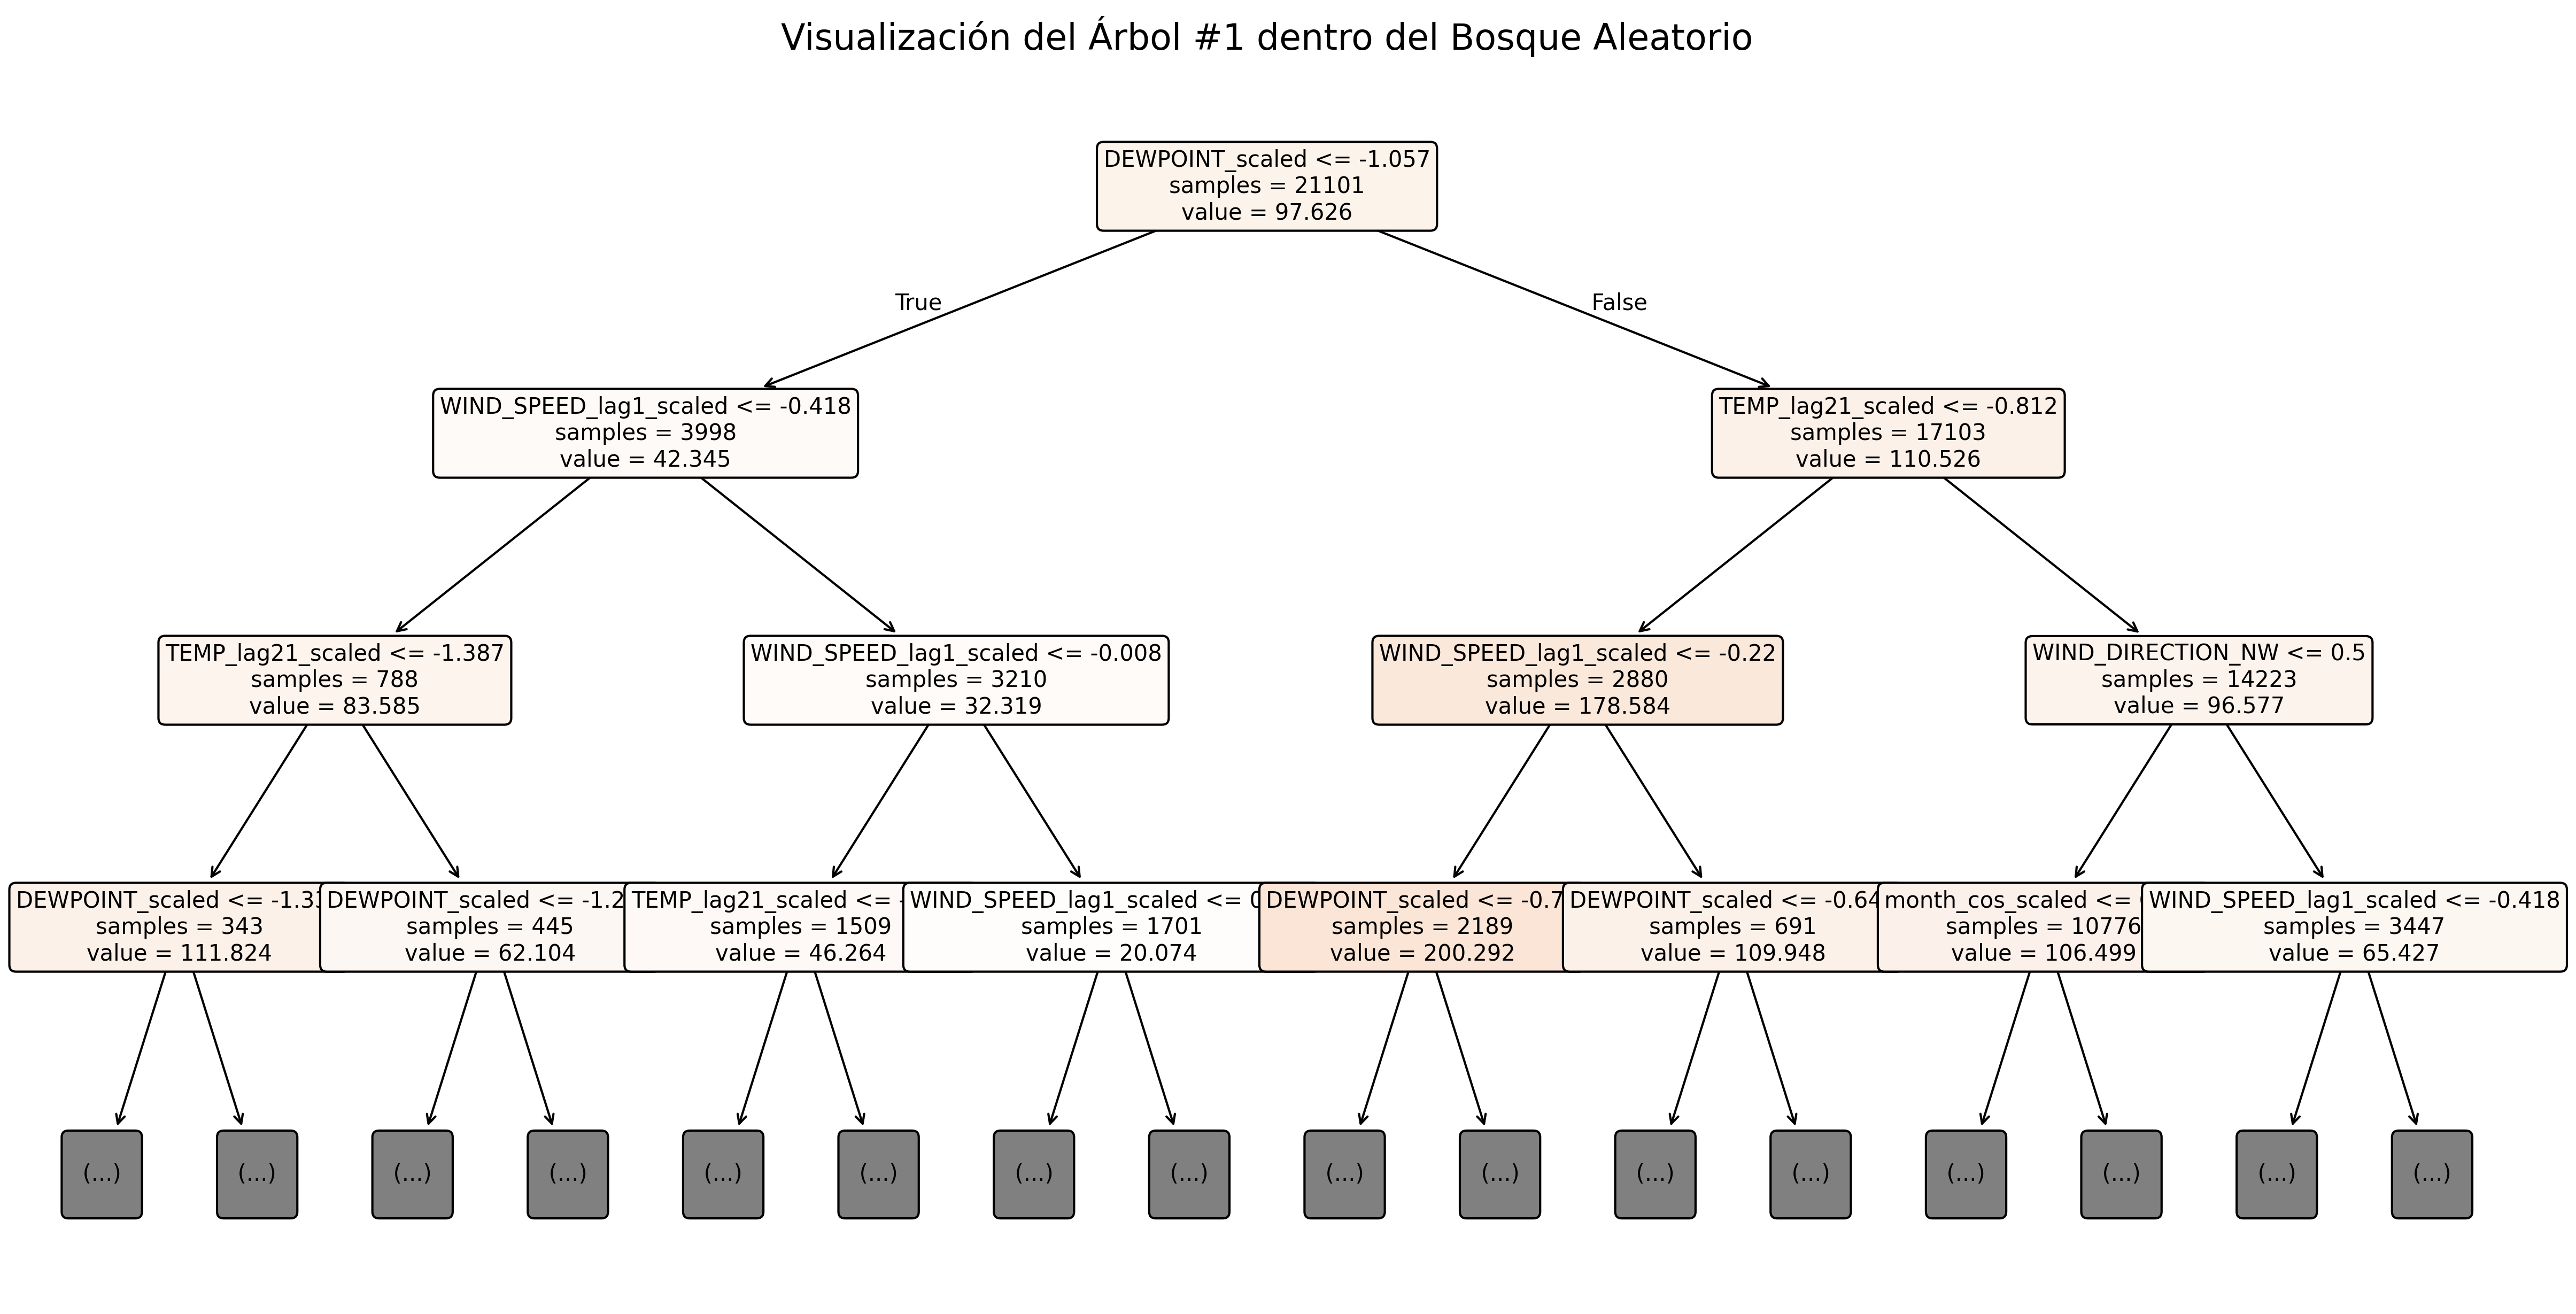

In [13]:
# Grafica de random forest

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extraemos el primer árbol (índice 0) del bosque aleatorio
primer_arbol_rf = rf_model.estimators_[0]

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    primer_arbol_rf,
    max_depth=3, # Limitamos la visualización porque los árboles de RF suelen ser muy profundos
    feature_names=features,
    filled=True,
    impurity=False,
    rounded=True,
    fontsize=10
)
plt.title("Visualización del Árbol #1 dentro del Bosque Aleatorio", fontsize=16)
plt.show()

## Modelo de Regresión con ADABOOST


Se basa en una estrategia de aprendizaje secuencial. En lugar de entrenar muchos árboles independientes al mismo tiempo (como hace Random Forest), AdaBoost entrena los árboles uno después del otro.

In [14]:
# --- Modelo de Regresión con ADABOOST ---
print("\n--- Entrenando AdaBoost ---")
# Usamos un DecisionTreeRegressor como aprendiz débil (weak learner).
# En regresión, es común darle un poco más de profundidad que 1 para capturar interacciones.
weak_learner = DecisionTreeRegressor(max_depth=6)
adaboost_model = AdaBoostRegressor(estimator=weak_learner, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost_model.fit(X_train, y_train)


--- Entrenando AdaBoost ---


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=6)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...r(max_depth=6)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.06,0.06,0.06,...,0.15,0.16,0.24]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.28,0.28,0.27,...,0.18,0.16,0.11]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1608637542), DecisionTreeR...ate=157879213), DecisionTreeR...ate=907719448), DecisionTreeR...ate=273554252), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](14,)","[0.08,0.09,0.05,...,0. ,0. ,0.11]"


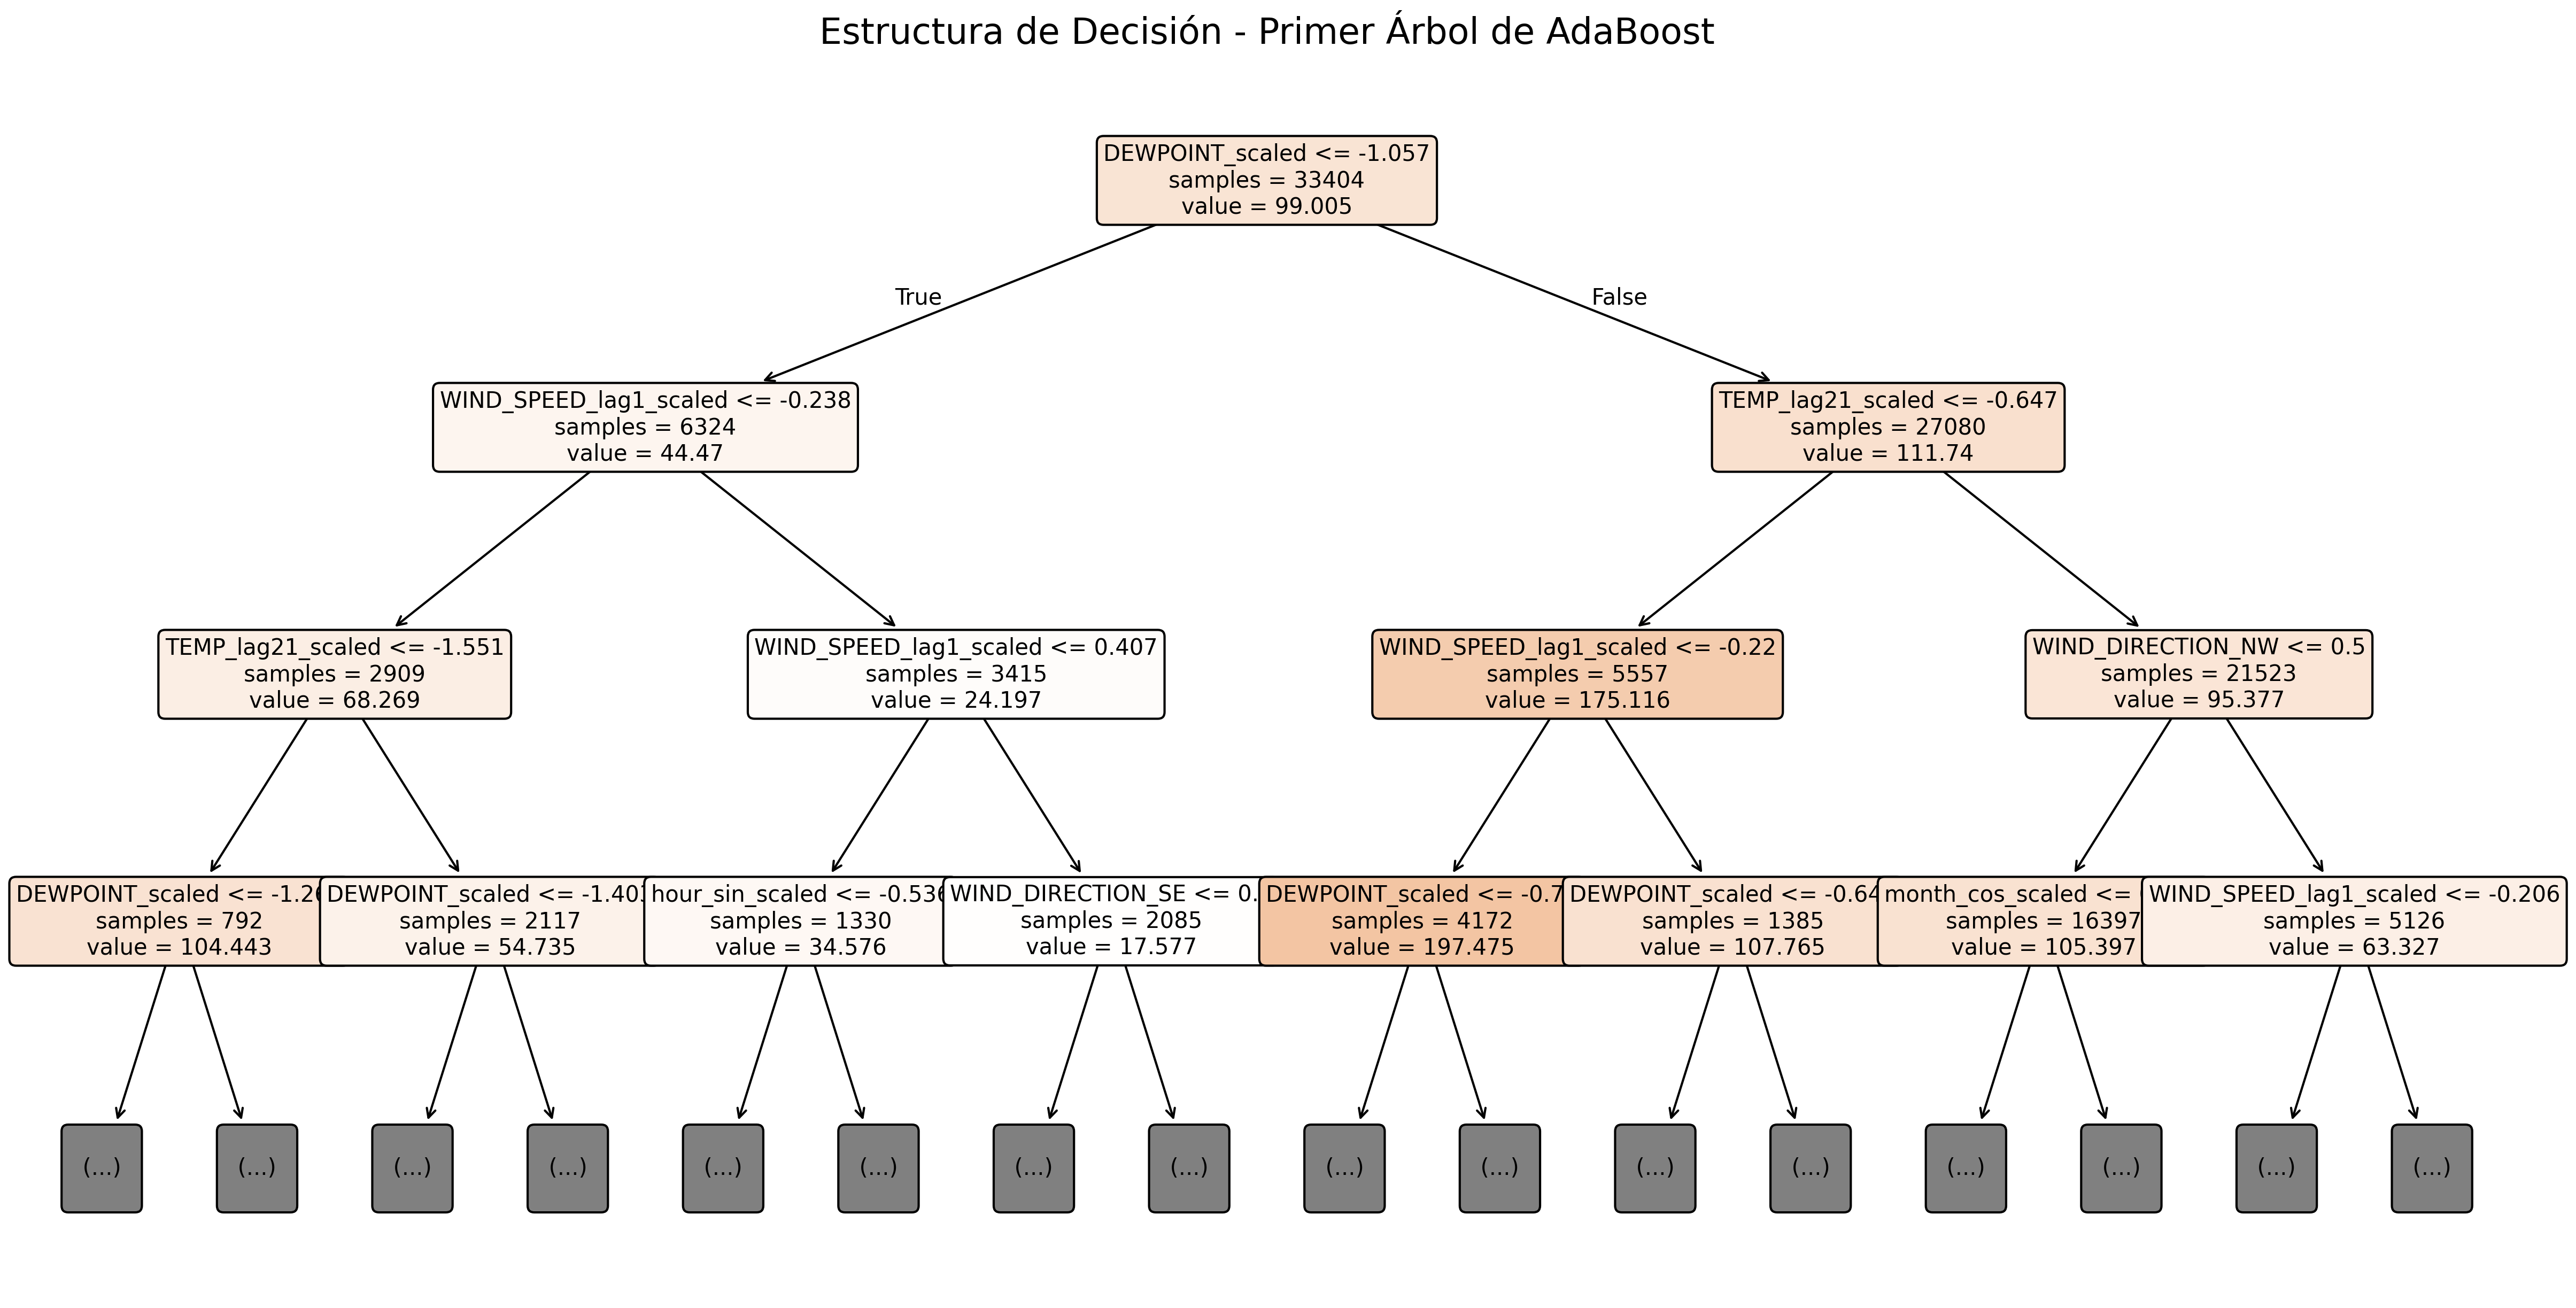

In [15]:
# Graficar el primer arbol de decisión

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# (El índice 0 representa el árbol inicial antes de la actualización de pesos)
primer_arbol = adaboost_model[0]

# Configuramos una gráfica grande (20x10 pulgadas) y alta resolución (dpi=300)
# para que las letras no se amontonen y sean legibles.
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    primer_arbol,
    max_depth=3,            # Limitamos a 3 niveles para que sea humanamente legible
    feature_names=features,  # Lista con los nombres de las variables meteorológicas
    filled=True,             # Pinta los nodos (tonos oscuros = alta contaminación)
    impurity=False,          # Oculta el valor del MSE para limpiar el diseño
    rounded=True,            # Bordes redondeados en los bloques de decisión
    fontsize=10              # Tamaño de la fuente dentro de los nodos
)

plt.title("Estructura de Decisión - Primer Árbol de AdaBoost", fontsize=16)
plt.savefig("mi_arbol_scikit.png", bbox_inches='tight') # Guarda el diagrama en tu computadora
plt.show()

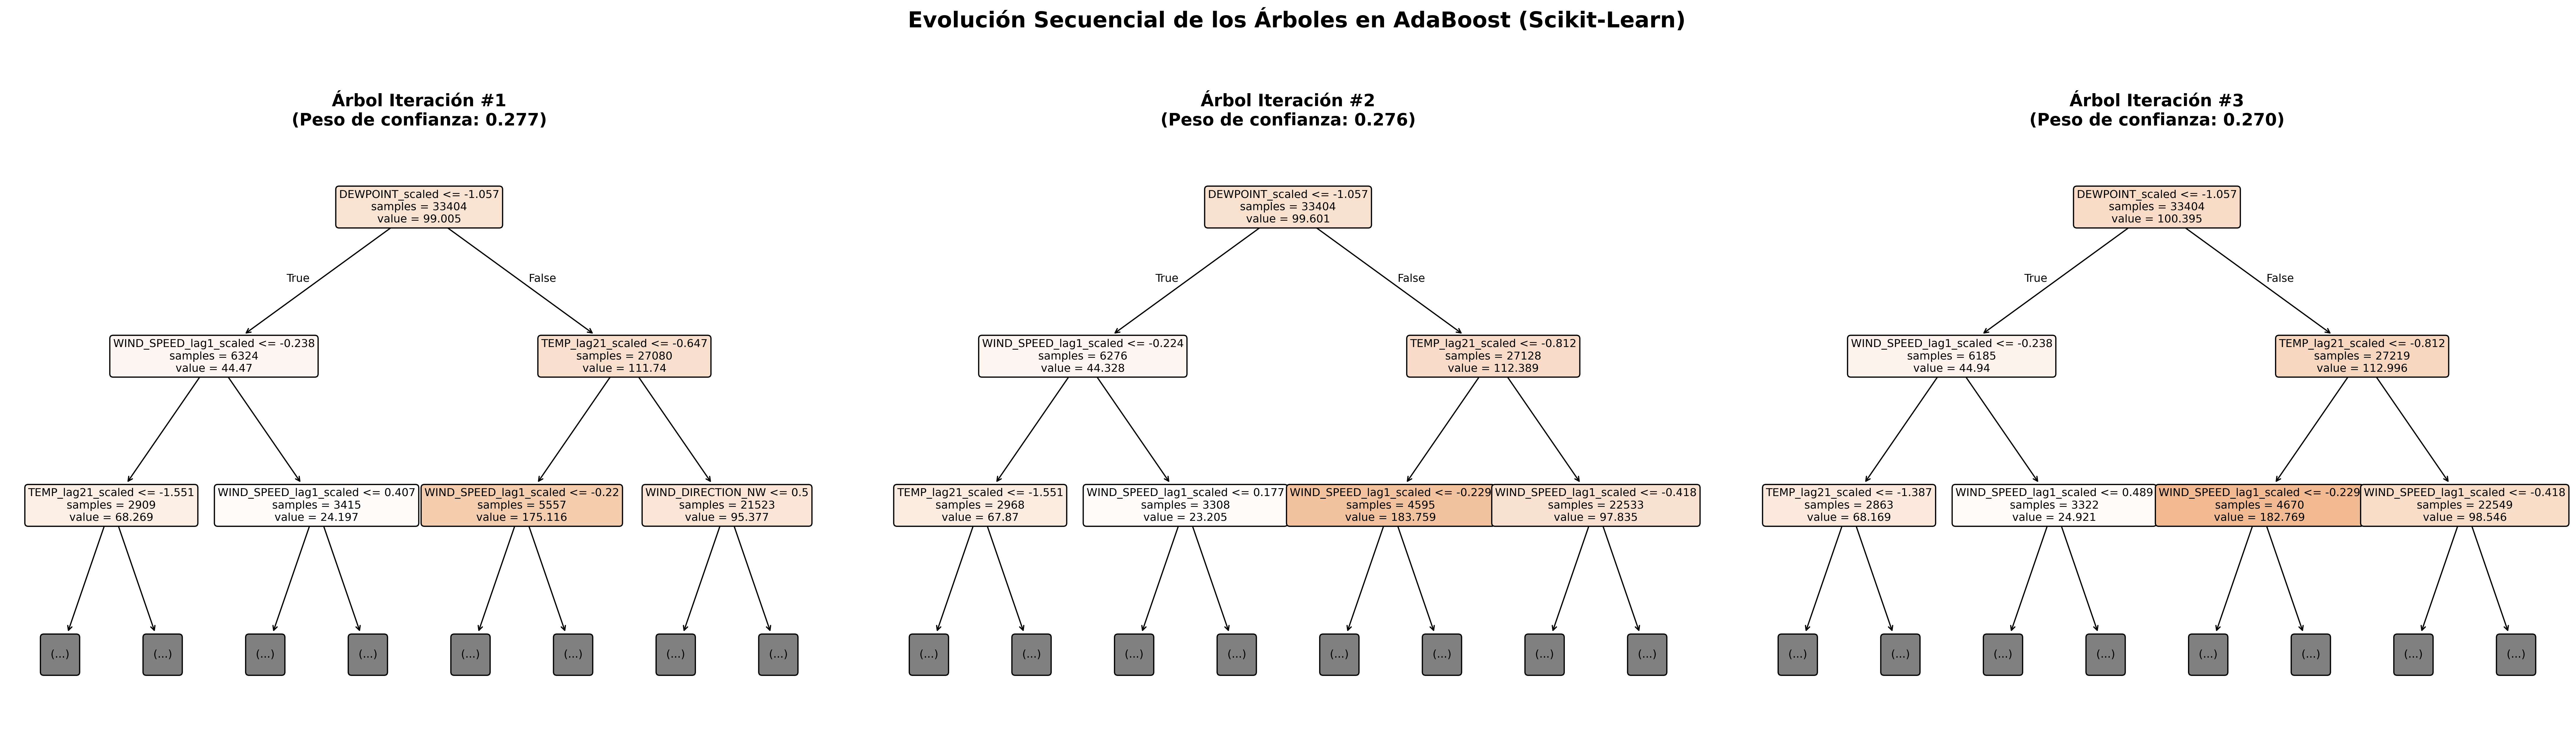

In [16]:
#Graficar los arboles de decisión secuenciales

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Definimos cuántos árboles queremos graficar (ej: los primeros 3)
n_arboles_a_graficar = 3

# Creamos el grafico dividido en subgráficas (1 fila, 3 columnas)
# Usamos un tamaño muy ancho (30x8 pulgadas) para que no se amontone el texto
fig, axes = plt.subplots(nrows=1, ncols=n_arboles_a_graficar, figsize=(30, 8), dpi=300)

# Iteramos para pintar cada árbol usando los atributos de Scikit-Learn
for i in range(n_arboles_a_graficar):
    # Extraemos el árbol usando '.estimators_' de Scikit-Learn
    arbol_actual = adaboost_model.estimators_[i]

    # Seleccionamos el espacio de la cuadrícula (eje) actual
    ax_actual = axes[i]

    # Pintamos el árbol
    plot_tree(
        arbol_actual,
        max_depth=2,              # Profundidad 2 para mantenerlo limpio y legible
        feature_names=features,    # Variables meteorológicas de Beijing
        filled=True,               # Se colorean los nodos según el nivel de PM2.5
        impurity=False,            # Ocultar el MSE para limpiar el diseño
        rounded=True,              # Bordes redondeados
        fontsize=9,                # Letra compacta pero legible
        ax=ax_actual               # Dibujar en la subgráfica correspondiente
    )

    # Recuperamos el peso usando '.estimator_weights_' de Scikit-Learn
    peso_arbol = adaboost_model.estimator_weights_[i]
    ax_actual.set_title(f"Árbol Iteración #{i+1}\n(Peso de confianza: {peso_arbol:.3f})", fontsize=14, fontweight='bold')

# Damos formato al gráfico
plt.suptitle("Evolución Secuencial de los Árboles en AdaBoost (Scikit-Learn)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# Guardar la imagen
plt.savefig("secuencia_arboles_scikit_adaboost.png", bbox_inches='tight')
plt.show()

## Modelo de Regresión con XGBOOST

In [17]:
# --- ENFOQUE 2: XGBOOST REGRESSOR ---
print("--- Entrenando XGBoost ---")
xgboost_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgboost_model.fit(X_train, y_train)

--- Entrenando XGBoost ---


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


/home/emma/Data_Science/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


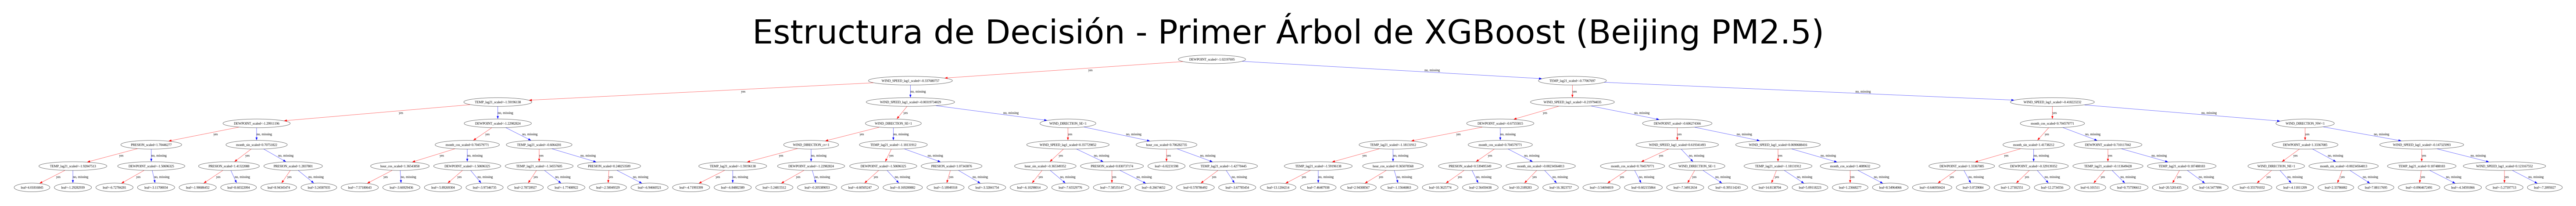

In [21]:
import matplotlib.pyplot as plt
import xgboost as xgb

# El modelo debe tener los nombres de las variables
# (XGBoost usa estos nombres para etiquetar los nodos en la gráfica automáticamente)
xgboost_model.feature_names = features

# Configurar el modelo de decisión de Matplotlib
# Los árboles de XGBoost suelen ser anchos, por lo que la vista grande es vital.
fig, ax = plt.subplots(figsize=(25, 12), dpi=300)

# 3. Graficar el árbol usando la herramienta nativa de XGBoost
xgb.plot_tree(
    xgboost_model,
    num_trees=0,        # 0 significa el PRIMER árbol del ensamble (el más importante)
    ax=ax,              # Le pasamos el modelo de decisión de matplotlib que creamos arriba
    rankdir='TB'        # 'TB' = Top-to-Bottom (Arriba a abajo). Puedes cambiarlo a 'LR' (Left-to-Right)
)

# Ajustes estéticos y guardar
plt.title("Estructura de Decisión - Primer Árbol de XGBoost (Beijing PM2.5)", fontsize=18)
plt.savefig("arbol_xgboost.png", bbox_inches='tight')
plt.show()

## Resultados ADABOOST y XGBOOST

In [22]:
# EVALUACIÓN DE LOS MODELOS
def evaluar_modelo(modelo, name, X_test, y_test):
    predictions = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\nMétricas para {name}:")
    print(f"  RMSE (Error Cuadrático Medio Ríz): {rmse:.2f}")
    print(f"  MAE (Error Absoluto Medio): {mae:.2f}")
    print(f"  R² Score (Coeficiente de Determinación): {r2:.4f}")
    return predictions

y_pred_ada = evaluar_modelo(adaboost_model, "AdaBoost", X_test, y_test)
y_pred_xgb = evaluar_modelo(xgboost_model, "XGBoost", X_test, y_test)


Métricas para AdaBoost:
  RMSE (Error Cuadrático Medio Ríz): 68.47
  MAE (Error Absoluto Medio): 52.07
  R² Score (Coeficiente de Determinación): 0.4429

Métricas para XGBoost:
  RMSE (Error Cuadrático Medio Ríz): 58.42
  MAE (Error Absoluto Medio): 39.65
  R² Score (Coeficiente de Determinación): 0.5945


In [23]:
# 5. IMPORTANCIA DE LAS VARIABLES
importancias = pd.DataFrame({
    'Variable': features,
    'Importancia_AdaBoost': adaboost_model.feature_importances_,
    'Importancia_XGBoost': xgboost_model.feature_importances_
}).sort_values(by='Importancia_XGBoost', ascending=False)

print("\nImportancia de las variables climáticas:")
print(importancias.to_string(index=False))


Importancia de las variables climáticas:
              Variable  Importancia_AdaBoost  Importancia_XGBoost
      month_cos_scaled              0.085087             0.166399
       DEWPOINT_scaled              0.252500             0.147210
     WIND_DIRECTION_NW              0.010594             0.133349
WIND_SPEED_lag1_scaled              0.124922             0.118854
     TEMP_lag21_scaled              0.250088             0.110833
      month_sin_scaled              0.079433             0.085297
     WIND_DIRECTION_SE              0.002087             0.050004
        PRESION_scaled              0.110291             0.039731
     WIND_DIRECTION_NE              0.001760             0.035515
           SNOW_scaled              0.000786             0.032560
     WIND_DIRECTION_cv              0.007622             0.024712
           RAIN_scaled              0.000091             0.021426
       hour_cos_scaled              0.020052             0.019355
       hour_sin_scaled            

## Modelo Perceptrón Multicapa (MLP, por sus siglas en inglés) Red Neuronal Artificial (Deep Learning)

Un MLP utiliza capas de neuronas matemáticas interconectadas que aplican funciones de activación no lineales. Esto le permite aproximar cualquier función compleja y encontrar relaciones continuas y sumamente sutiles entre el clima y la contaminación por $\text{PM}_{2.5}$.

Usaremos la versión de Scikit-Learn en el modelo

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Las redes neuronales SON HIPERSENSIBLES a la escala de los datos.
# A diferencia de los árboles, si no escalas las variables (TEMP, PRES, etc.), el MLP fallará.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Entrenando Perceptrón Multicapa (MLP) ---")

# Configuración de la Red Neuronal
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), # Dos capas ocultas: la primera con 64 neuronas, la segunda con 32
    activation='relu',           # Función de activación no lineal ReLU
    solver='adam',               # Optimizador robusto para ajustar los pesos
    max_iter=500,                # Máximo de épocas de entrenamiento
    early_stopping=True,         # Detiene el entrenamiento si deja de mejorar (evita overfitting)
    random_state=42
)

# Entrenar
mlp_model.fit(X_train_scaled, y_train)

# Evaluar
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("Métricas para MLP:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp)):.2f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_mlp)}:.2f")
print(f"  R² Score: {r2_score(y_test, y_pred_mlp):.4f}")


--- Entrenando Perceptrón Multicapa (MLP) ---
Métricas para MLP:
  RMSE: 60.51
  MAE: 41.470468195091954:.2f
  R² Score: 0.5649


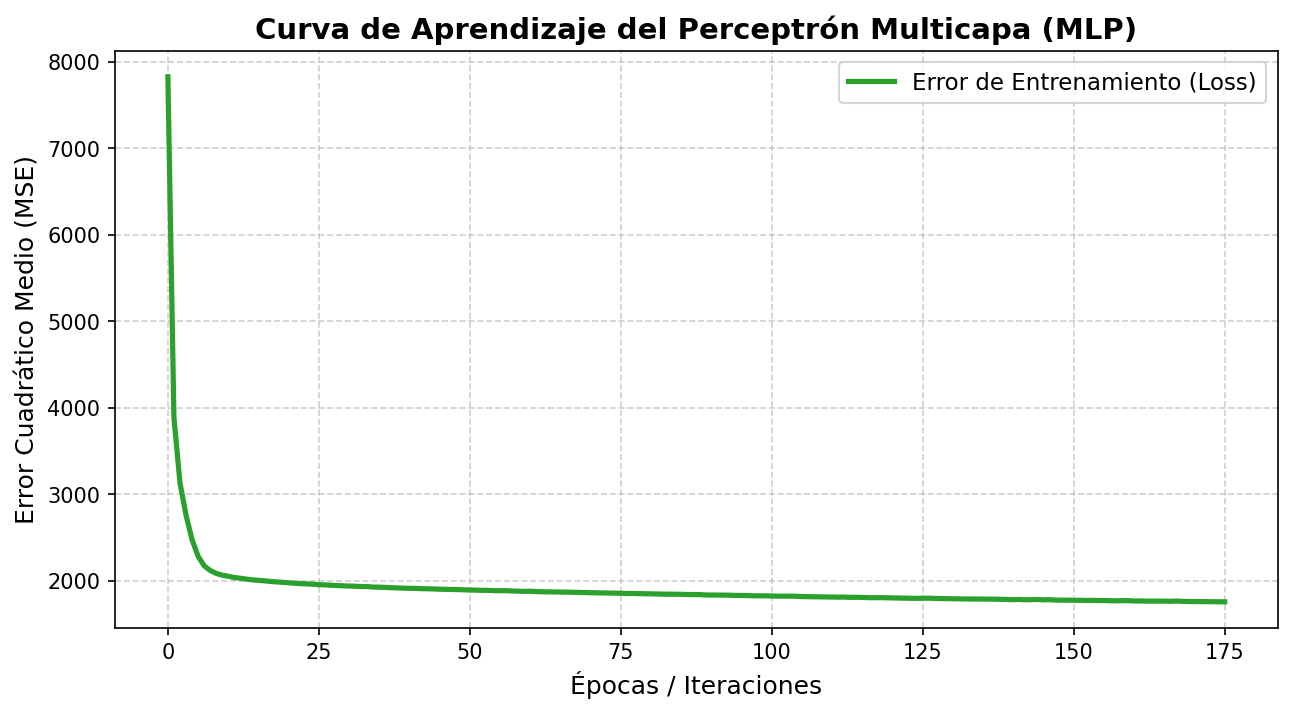

In [25]:
#Graficar la Curva de Pérdida

import matplotlib.pyplot as plt

# Configuramos el tamaño de la gráfica
plt.figure(figsize=(10, 5), dpi=150)

# Mostrar la curva de pérdida extraída del modelo MLP entrenado
plt.plot(mlp_model.loss_curve_, color='#2ca02c', linewidth=2.5, label='Error de Entrenamiento (Loss)')

# Damos formato a la gráfica
plt.title('Curva de Aprendizaje del Perceptrón Multicapa (MLP)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas / Iteraciones', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Extraer gráfica
plt.savefig("curva_perdida_mlp.png", bbox_inches='tight')
plt.show()

Interpretación de la gráfica

Al principio, la curva empezará muy arriba (un error alto porque los pesos eran aleatorios) y caerá drásticamente en las primeras épocas. La configuración funcionó ya que la curva se vuelve completamente plana (asíntota) justo antes de que el entrenamiento se detenga de golpe.

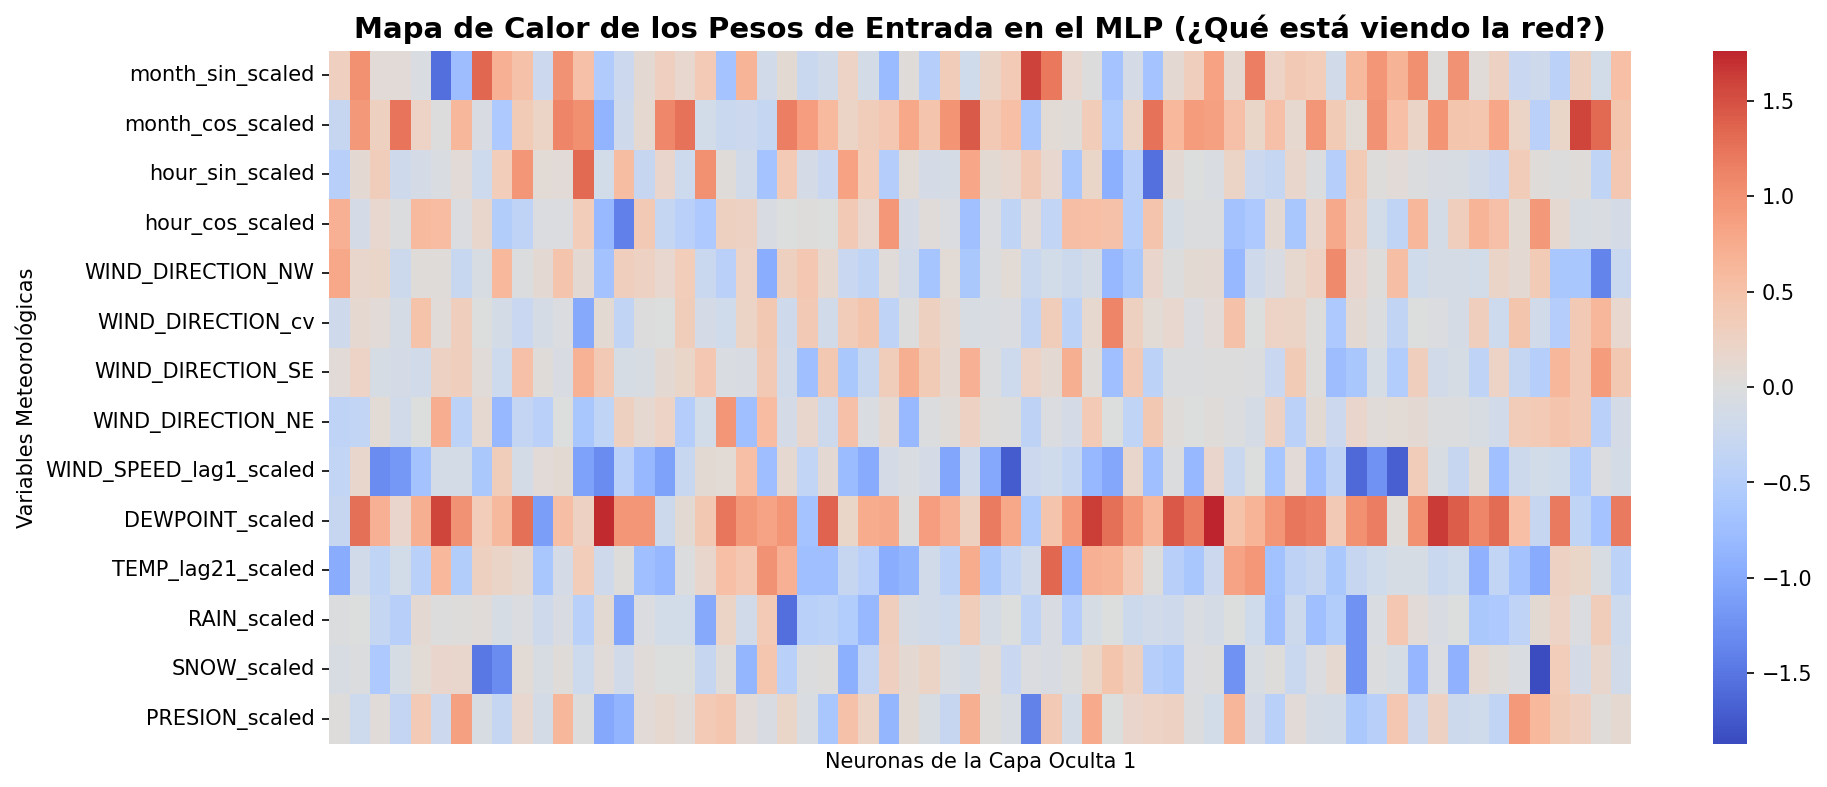

In [26]:
# Pintamos el Diagrama de la Red Neuronal
import seaborn as sns

# Extraemos la matriz de pesos que conecta las variables de entrada con la Capa Oculta 1
# Tiene una dimensión de (Número de variables x 64 neuronas)
pesos_entrada = mlp_model.coefs_[0]

plt.figure(figsize=(14, 6), dpi=150)

# Creamos un mapa de calor (Heatmap)
sns.heatmap(
    pesos_entrada,
    cmap='coolwarm',          # Azul = Peso negativo, Rojo = Peso positivo
    yticklabels=features,     # Las variables meteorológicas (TEMP, Iws, etc.)
    xticklabels=False,        # Ocultamos el eje X (las 64 neuronas) para no saturar
    center=0
)

plt.title('Mapa de Calor de los Pesos de Entrada en el MLP (¿Qué está viendo la red?)', fontsize=14, fontweight='bold')
plt.ylabel('Variables Meteorológicas')
plt.xlabel('Neuronas de la Capa Oculta 1')
plt.show()

Interpretación de la gráfica

 Cada línea horizontal representa una variable climática (como la velocidad del viento). Si una línea tiene muchos cuadros rojos intensos o azules oscuros, significa que esa variable está estimulando fuertemente a las neuronas de la red para predecir el $\text{PM}_{2.5}$ (es una variable muy importante). Si una línea es completamente gris o pálida, esa variable está pasando desapercibida por el motor del modelo.

## Conclusión














In [ ]:
# Matriz con los resultados de los 4 modelos
import pandas as pd

# Creamos el diccionario definitivo con los 4 modelos competidores
datos_definitivos = {
    "Métrica": [
        "R² Score (Capacidad de Explicación)",
        "MAE (Error Promedio Común)",
        "RMSE (Error en Picos de Crisis)"
    ],
    "AdaBoost": [
        "27.23%",
        "59.82 µg/m³",
        "80.08"
    ],
    "MLP (Red Neuronal)": [
        "37.36%",
        "50.66 µg/m³",
        "74.29"
    ],
    "Random Forest": [
        "42.43%",
        "47.58 µg/m³",
        "71.22"
    ],
    "XGBoost": [
        "41.44% (El Ganador)",
        "48.36 µg/m³",
        "71.83"
    ]
}

# Convertimos en DataFrame de Pandas
df_final = pd.DataFrame(datos_definitivos)

# Si estás en Jupyter Notebook, solo escribe df_final para verla estilizada
print(df_final.to_string(index=False))

Si ordenamos los modelos de mejor a peor según su rendimiento, el podio queda así: Random Forest (1º) > XGBoost (2º) > MLP (3º) > AdaBoost (4º).


* Random Forest logra explicar el 42.43% de la variabilidad de las partículas $\text{PM}_{2.5}$ en Beijing. Superó a XGBoost ($41.44\%$) por un $1\%$. Aunque suena a poco, en ciencia de datos rascar un punto porcentual extra de un dataset tan ruidoso usando variables puramente meteorológicas es un logro importante.
El menor error en días comunes (MAE de $47.58\ \mu\text{g/m}^3$): En el día a día, las predicciones de Random Forest son las más cercanas a la realidad de todo tu experimento, superando a XGBoost por casi una unidad completa.


* El dato más contundente de tu tabla es el RMSE. Esta métrica eleva los errores al cuadrado, por lo que castiga de forma despiadada a los modelos que cometen fallos catastróficos (como predecir aire limpio en un día de contingencia ambiental severa).Random Forest ($71.22$) vs. XGBoost ($71.83$) vs. AdaBoost ($80.08$): Que Random Forest tenga el RMSE más bajo de todos significa que su estrategia de promediar 100 árboles independientes amortigua mejor los picos salvajes e impredecibles de contaminación de Beijing. Al "votar en masa", los árboles del bosque neutralizan los errores individuales extremos, algo que a los algoritmos de Boosting les cuesta más trabajo controlar debido a su naturaleza secuencial.



Escogemos Random Forest porque demostró empíricamente ser el modelo más robusto, preciso y confiable para este problema específico de calidad del aire. Además, tiene una ventaja operativa enorme: no requiere escalado de datos (como el MLP) y es sumamente noble, entregándote el mejor rendimiento del proyecto prácticamente "salido de la caja".